<a href="https://colab.research.google.com/github/brhan29/makemore/blob/main/makemore_p3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from urllib.request import urlretrieve
urlretrieve(
    "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt",
    "names.txt"
)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(set(''.join(words)))
stoi = {s:(i+1) for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [ ]:
# context size parameter
p_context_size = 3

def build_dataset(words):
  X = []; Y = []
  for word in words:
    context = [0] * p_context_size
    for ch in word + '.':
      X.append(context); Y.append(stoi[ch])
      context = context[1:] + [stoi[ch]]
  return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)

# 80/10/10 split
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xval,Yval = build_dataset(words[n1:n2])
Xtest,Ytest = build_dataset(words[n2:])

In [ ]:
# More model params
p_hidn = 200
p_edim = 10

# We use Kaiming initialization for W1. tanh has gain 5/3
# From the paper https://arxiv.org/abs/1502.01852. Really cool paper!
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, p_edim), generator=g)
W1 = torch.randn((p_context_size*p_edim, p_hidn), generator=g) * ((5/3)/((p_context_size*p_edim)**(0.5)))
# We don't need bias here since we use batch norm which has its own bias
# b1 = torch.randn(p_hidn, generator=g)
# We initialize W2 and b2 to reasonably small numbers just so logits don't end up extreme
W2 = torch.randn((p_hidn, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.1

# BN params
bngain = torch.ones((1, p_hidn))
bnbias = torch.zeros((1, p_hidn))
# This initialization really doesn't matter, momentum kills initial running values
bnmean_running = torch.zeros((1, p_hidn))
bnstd_running = torch.ones((1, p_hidn))

params = [C, W1, W2, b2, bngain, bnbias]
for p in params:
  p.requires_grad = True

0/200000, loss is 3.3233799934387207
20000/200000, loss is 2.5691049098968506
40000/200000, loss is 2.2446048259735107
60000/200000, loss is 2.0800390243530273
80000/200000, loss is 2.2916791439056396
100000/200000, loss is 2.3710455894470215
120000/200000, loss is 1.6412447690963745
140000/200000, loss is 2.2244760990142822
160000/200000, loss is 2.095475196838379
180000/200000, loss is 2.0269064903259277


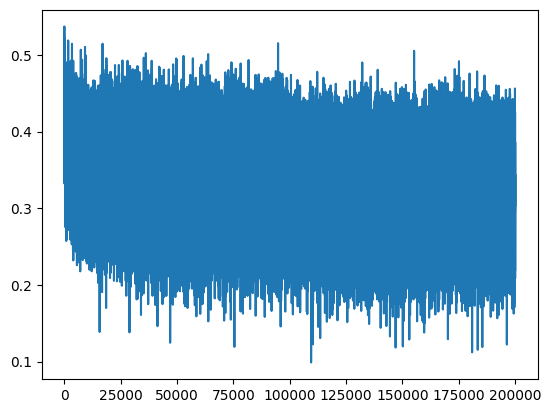

In [ ]:
# Optimizer
num_steps = 200000
batch_size = 32
lossi = []

for i in range(num_steps):

  # make minibatch
  batch = torch.randint(Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[batch], Ytr[batch]

  # Forward pass
  emb = C[Xb].view(batch_size, -1)
  # hidden layer preactivation
  hpreact = emb @ W1
  # BN layer
  bnmeani = hpreact.mean(0, keepdim = True)
  bnstdi = hpreact.std(0, keepdim = True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    # Running average with momentum 0.001
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  hact = torch.tanh(hpreact)
  logits = hact @ W2 + b2
  loss = F.cross_entropy(logits, Yb)
  lossi.append(loss.log10().item())

  # Backprop
  for p in params:
    p.grad = None
  loss.backward()
  # simple learning rate decay
  lr = 0.1 if i<100000 else 0.01
  for p in params:
    p.data -= p.grad * lr

  if i % 20000 == 0:
    print(f'{i}/200000, loss is {loss}')

plt.plot(lossi)

In [ ]:
# We can also compute averages via passing the entire training set, which requires some more compute
train_hpreact = C[Xtr].view(Xtr.shape[0],-1)@W1
bnmean_total = train_hpreact.mean(0, keepdim=True)
bnstd_total = train_hpreact.std(0, keepdim=True)
print(bnmean_total - bnmean_running)
print(bnstd_total - bnstd_running)

tensor([[ 1.2909e-02, -2.6876e-03, -2.3557e-03, -1.4749e-03, -1.2806e-02,
          1.1892e-02,  8.3919e-03,  5.1956e-03,  5.8835e-03,  2.0012e-02,
          1.6195e-02,  2.3317e-04,  1.1398e-03,  1.1212e-02, -7.6050e-04,
         -1.4322e-02,  3.5344e-03, -2.1546e-03,  1.9711e-02,  2.0254e-02,
         -9.3313e-03, -2.3016e-02, -1.3875e-02, -3.7711e-03, -2.9025e-03,
         -1.9706e-03, -1.3766e-03, -2.8957e-03,  5.5074e-03,  3.8065e-03,
          1.1308e-02, -4.8819e-03, -5.9575e-03, -2.9385e-03, -3.9338e-03,
         -6.9607e-03, -7.9083e-04,  6.2476e-03, -1.1711e-02, -2.5961e-03,
          8.2355e-03,  2.3309e-02, -2.1958e-03, -4.8133e-03, -2.3478e-04,
         -4.5865e-03, -5.2385e-03,  1.1520e-02,  1.6227e-02,  1.2811e-02,
         -1.0793e-03,  7.3839e-03,  8.6749e-03,  2.9888e-03,  2.3866e-03,
         -3.5572e-04, -2.0706e-03,  7.4171e-03, -8.5063e-03,  1.9286e-03,
          1.0809e-02,  1.2800e-02,  9.2541e-03,  9.3734e-04,  5.8270e-04,
          1.6137e-02,  8.1359e-03,  6.

In [ ]:
# By the way, the paper https://arxiv.org/abs/1502.03167 motivates batch norm really well!
# We now evaluate on the entire train, val, test sets
# Basically same as forward pass in train time, but we freeze batchnorm scaling to running averages

@torch.no_grad()
def eval_loss(X, Y):
  hpreact = C[X].view(X.shape[0],-1) @ W1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  logits = torch.tanh(hpreact) @ W2 + b2
  return F.cross_entropy(logits, Y).item()

print(f'Validation set loss is {eval_loss(Xval, Yval)}')
print(f'Test set loss is {eval_loss(Xtest, Ytest)}')

Validation set loss is 2.105558395385742
Test set loss is 2.1071999073028564


In [ ]:
# Now we pytorchify our code by making python classes that mimic torch.nn classes
# We will use this to make a deeper network with five hidden layers

# See https://docs.pytorch.org/docs/2.14/generated/torch.nn.Linear.html for nn.Linear, which we mimic
class Linear:

  # Linear initialization scales by sqrt(fan_in), gain of activation needs to be added later apart from class
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in,fan_out), generator=g) / (fan_in ** 0.5)
    self.bias = torch.randn(fan_out, generator=g) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

# See https://docs.pytorch.org/docs/2.14/generated/torch.nn.BatchNorm1d.html for nn.BatchNorm1d
class BatchNorm1D:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    # Since batchnorm performs differently in training and inference
    self.training = True
    # Batchnorm params
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # Global tracking variables
    # We track var instead of std; it's mathematically very close (?)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      xmean = x.mean(0, keepdims=True)
      xvar = x.var(0, keepdims=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    self.out = self.gamma * (x - xmean) / torch.sqrt(xvar + self.eps) + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# See nn.tanh at https://docs.pytorch.org/docs/2.14/generated/torch.nn.Tanh.html
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [ ]:
# Restate parameters here just for clarity
p_context_size = 3
p_hidn = 200
p_edim = 10

C = torch.randn((27, p_edim), generator=g)
# We use the motif linear layer, batchnorm, nonlinearity
# Batchnorm at final layer is optional but just helps logits no explode
# Five hidden layers, each with p_hidn neurons
layers = [
    Linear(p_edim * p_context_size, p_hidn, bias = False), BatchNorm1D(p_hidn), Tanh(),
    Linear(p_hidn, p_hidn, bias = False), BatchNorm1D(p_hidn), Tanh(),
    Linear(p_hidn, p_hidn, bias = False), BatchNorm1D(p_hidn), Tanh(),
    Linear(p_hidn, p_hidn, bias = False), BatchNorm1D(p_hidn), Tanh(),
    Linear(p_hidn, p_hidn, bias = False), BatchNorm1D(p_hidn), Tanh(),
    Linear(p_hidn, 27, bias = False), BatchNorm1D(27),
]

# We also test with this to see pathologies
# layers = [
#     Linear(p_edim * p_context_size, p_hidn, bias = False), Tanh(),
#     Linear(p_hidn, p_hidn, bias = False), Tanh(),
#     Linear(p_hidn, p_hidn, bias = False), Tanh(),
#     Linear(p_hidn, p_hidn, bias = False), Tanh(),
#     Linear(p_hidn, p_hidn, bias = False), Tanh(),
#     Linear(p_hidn, 27, bias = False),
# ]

with torch.no_grad():
  # We want to initialize last layer to make unconfident logits for better training
  layers[-1].gamma *= 0.1
  # layers[-1].weight *= 0.1
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      # Gain of tanh nonlinearity
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
  p.requires_grad = True

In [ ]:
# Optimizer
num_steps = 200000
batch_size = 32
lossi = []
# Tracks scale of updates versus scale of parameter
# Good training diagnostic for setting lr, etc.
ud = []

for i in range(num_steps):
  # Make minibatch
  ix = torch.randint(Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  # Forward pass
  x = C[Xb].view(batch_size, -1)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb)

  # Backward pass
  # We want to retain gradients of out for debug purposes
  # I also don't believe the nn layers have .outs...? we have it for debugging
  for layer in layers:
    layer.out.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()

  # Updates
  lr = 0.05 if i<100000 else 0.005
  for p in parameters:
    p.data -= lr * p.grad

  if i % 10000 == 0:
    print(f'{i} / 200000, loss is {loss.item()}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    # Works because every parameter is a vector
    ud.append([((lr * p.grad).std() / p.std()).log10().item() for p in parameters])

0 / 200000, loss is 1.993097186088562
10000 / 200000, loss is 2.055386543273926
20000 / 200000, loss is 2.1991658210754395
30000 / 200000, loss is 1.9605194330215454
40000 / 200000, loss is 2.312922716140747
50000 / 200000, loss is 2.114955425262451
60000 / 200000, loss is 2.0249366760253906
70000 / 200000, loss is 2.028346300125122
80000 / 200000, loss is 2.486558675765991
90000 / 200000, loss is 1.7384501695632935
100000 / 200000, loss is 1.5966829061508179
110000 / 200000, loss is 1.9938063621520996
120000 / 200000, loss is 2.3364930152893066
130000 / 200000, loss is 2.066612482070923
140000 / 200000, loss is 1.7186908721923828
150000 / 200000, loss is 2.0272979736328125
160000 / 200000, loss is 2.1095266342163086
170000 / 200000, loss is 2.06003999710083
180000 / 200000, loss is 1.887485384941101
190000 / 200000, loss is 2.375943422317505


layer number 2: mean +0.00, std +0.63, saturated 3.14%
layer number 5: mean +0.00, std +0.64, saturated 2.92%
layer number 8: mean +0.00, std +0.64, saturated 2.50%
layer number 11: mean +0.00, std +0.64, saturated 2.47%
layer number 14: mean -0.00, std +0.65, saturated 2.48%


Text(0.5, 1.0, 'activation distribution')

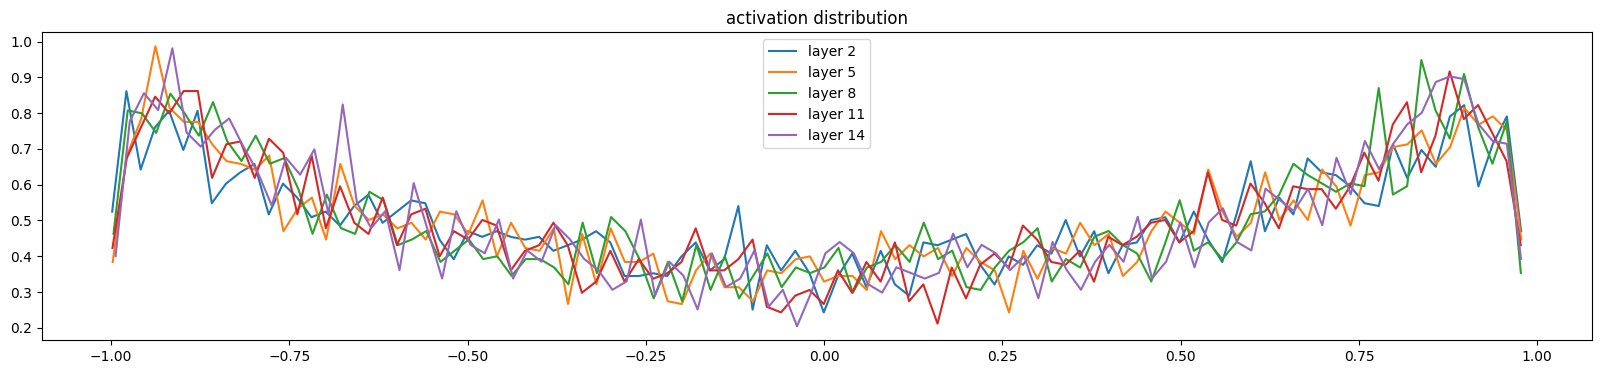

In [ ]:
# Okay so we locked the model at the first iteration to see how healthy the initialization is
# We do this with four plots
# Plot 1 shows the distribution of tanh outputs to see how saturated these neurons are; we want to see pretty low saturation for healthy gradient flow
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print(f'layer number %d: mean %+.2f, std %+.2f, saturated %.2f%%' % (i, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
    # See https://docs.pytorch.org/docs/2.14/generated/torch.histogram.html for torch.histogram; kinda complicated function
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i}')
plt.legend(legends)
plt.title('activation distribution')

# Here are some things to look out for: at initialization, we don't want too much saturation (> 5-10%)
# Also if the distribution of activations change between layers ('diffuses' or 'squeezes'), that is a sign of bad initialization,
# since we want the distribution of activations to stay roughly consistent between layers for good gradient flow

layer number 1: mean +0.00, std +0.00
layer number 3: mean -0.00, std +0.00
layer number 5: mean -0.00, std +0.00
layer number 7: mean +0.00, std +0.00
layer number 9: mean +0.00, std +0.00


Text(0.5, 1.0, 'activation gradient distribution')

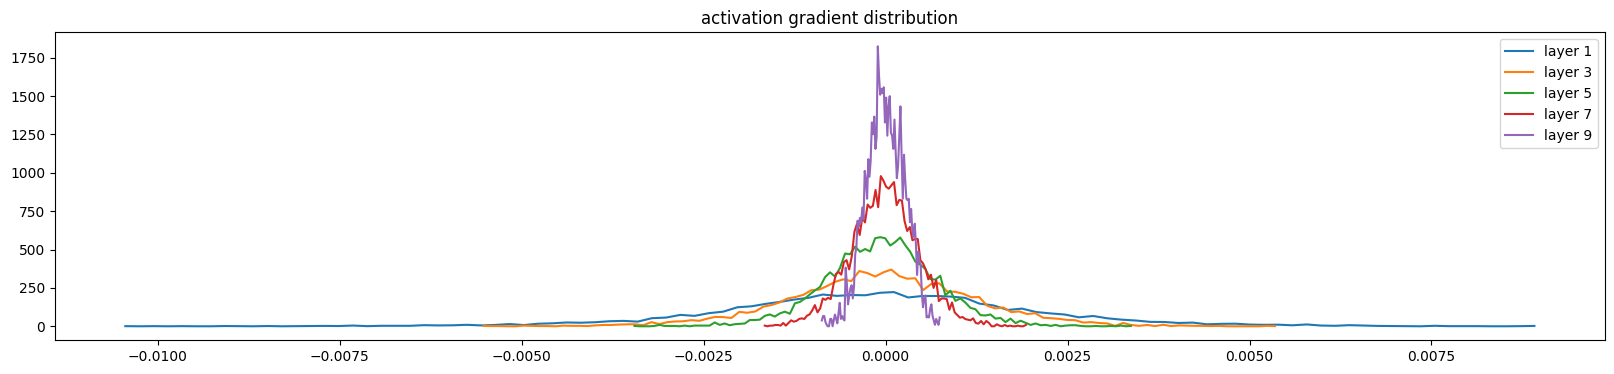

In [ ]:
# Second plot is histogram of gradients of activations in the network
# If it scales 'up' (i.e. distribution diffuses deeper into network because, say, we overestimated gain), then
# gradients would be much larger ('diffuse') at earlier layers
plt.figure(figsize=(20,4))
legends = []
for i,layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print(f'layer number %d: mean %+.2f, std %+.2f' % (i, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i}')
plt.legend(legends)
plt.title('activation gradient distribution')
# We generated the below plot using the model without batchnorms with gain 5 (overestimate) to demonstrate pathologies

weight (27, 10) | mean -0.000000 | std 9.225660e-03 | grad:data ratio 9.219249e-03
weight (30, 200) | mean -0.000088 | std 5.226206e-03 | grad:data ratio 1.715311e-02
weight (200, 200) | mean -0.000016 | std 4.056188e-03 | grad:data ratio 3.408184e-02
weight (200, 200) | mean +0.000009 | std 3.494237e-03 | grad:data ratio 2.948685e-02
weight (200, 200) | mean -0.000012 | std 3.240130e-03 | grad:data ratio 2.744299e-02
weight (200, 200) | mean -0.000002 | std 3.176777e-03 | grad:data ratio 2.664865e-02
weight (200, 27) | mean +0.000023 | std 8.684936e-03 | grad:data ratio 7.061611e-02


Text(0.5, 1.0, 'Grad distribution for linear weight')

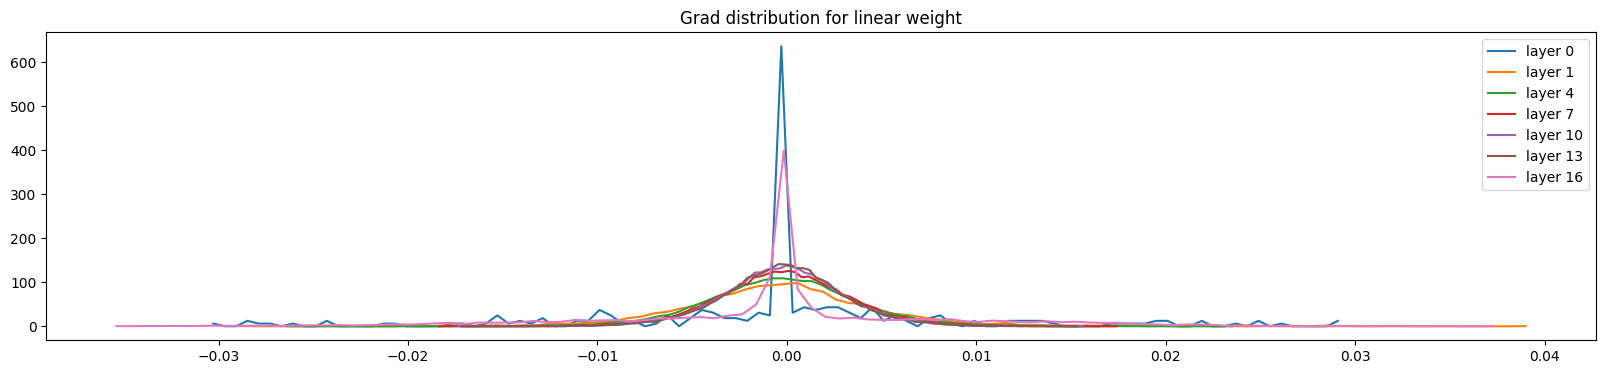

In [ ]:
# We now plot, for linear layers, the histogram of gradients for the weight matrices
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print(f'weight %s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i}')
plt.legend(legends)
plt.title('Grad distribution for linear weight')

# A little pathological at initialization; the grad:data ratio for the final linear layer is really high, but it trains fine and at
# Later iterations its fine
# Yup, after 2000 iterations the grad distributions even out

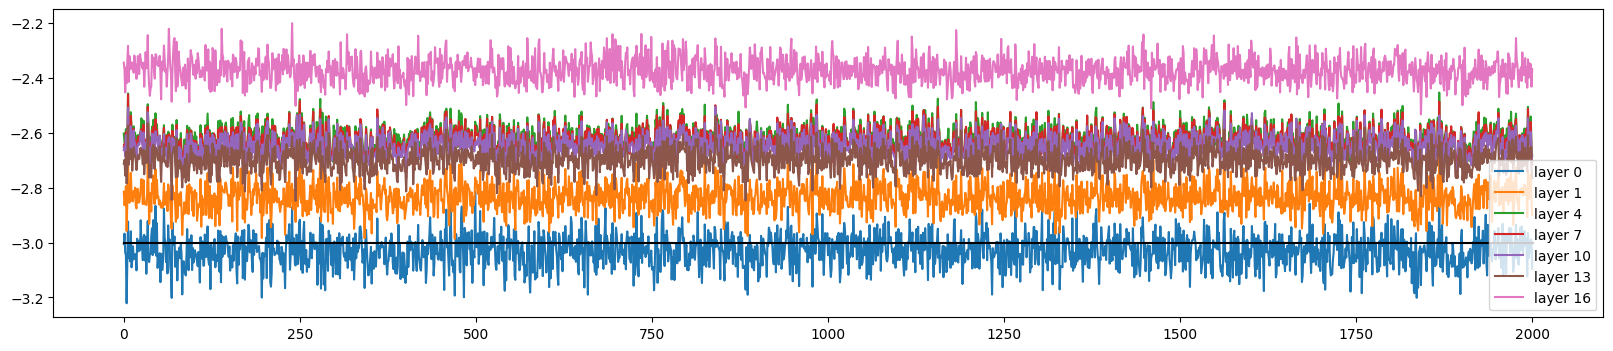

In [ ]:
# Finally we plot, for each weight parameter in linear layers, the change / parameter value ratio
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append(f'layer {i}')
plt.legend(legends)
plt.plot([0, len(ud)], [-3, -3], 'k')
# We want around -3 (1e-3), a rough heuristic for healthy training

In [ ]:
# Oops forgot to change BNs to inference...
for layer in layers:
  layer.training = False

@torch.no_grad()
def new_eval_loss(X, Y):
  x = C[X].view(-1,p_context_size * p_edim)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Y)
  return loss

print(f'Validation set loss is {new_eval_loss(Xval, Yval)}')
print(f'Test set loss is {new_eval_loss(Xtest, Ytest)}')

NameError: name 'layers' is not defined

In [ ]:
# Generate names
for _ in range(20):
  out = []
  context = [0] * p_context_size
  while True:
    x = C[context].view(-1)
    for layer in layers:
      x = layer(x)
    probs = torch.softmax(x, dim=0)
    next = torch.multinomial(probs, 1, replacement=True).item()
    out.append(next)
    if next == 0:
      break
    context = context[1:] + [next]
  print(''.join(itos[i] for i in out))

shn.
nal.
hkm.
nam.
nan.
den.
mmn.
len.
mmn.
mnn.
col.
sco.
mnn.
llin.
skn.
lmn.
kashna.
bren.
mjniv.
mno.


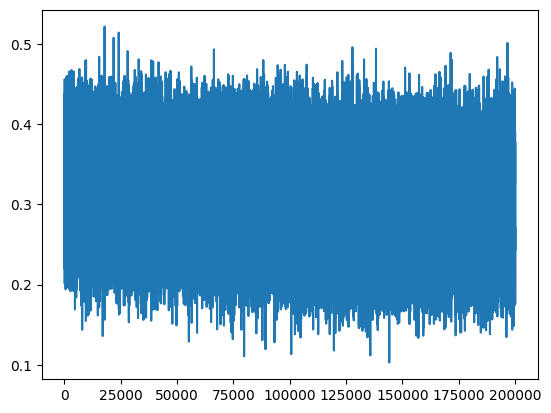

In [ ]:
plt.plot(lossi)